In [3]:
import os, math, random
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, callbacks
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
BASE = "/content/drive/MyDrive/HCI Project/Datasets/ibdts_processed_data/ibdts_processed_data"
VIDEO_DIR = os.path.join(BASE, "3D_Motion_Videos")
HR_DIR    = os.path.join(BASE, "hr")

In [5]:
FPS = 30
INTERVAL_SECONDS = 4
INTERVAL_FRAMES = FPS * INTERVAL_SECONDS
N_FRAMES = 8
IMG_SIZE = (128, 128)
BATCH_SIZE = 4
EPOCHS = 20
SEED = 42

In [6]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
def list_videos(video_dir):
    """Return list of mp4 (or other) video files in folder."""
    vids = sorted([str(p) for p in Path(video_dir).glob("*.mp4")])
    return vids

## Model A: Predicts heart rate in the next interval from heart rates and videos in the previous interval

In [14]:
def get_hr_values(hr_csv_path):
    df = pd.read_csv(hr_csv_path)
    if 'HR' in df.columns:
        vals = df['HR'].values.astype(float)
    elif 'time_sec' in df.columns and df.select_dtypes(include='number').shape[1] >= 2:
        # if there is time_sec + HR-like column, pick the second numeric column
        num_cols = df.select_dtypes(include='number').columns
        vals = df[num_cols[1]].values.astype(float)
    else:
        num_cols = df.select_dtypes(include='number').columns
        if len(num_cols) == 0:
            raise ValueError(f"No numeric HR column in {hr_csv_path}")
        vals = df[num_cols[0]].values.astype(float)
    return vals

In [15]:
def hr_interval_features(hr_series, start_idx, end_idx):
    seg = hr_series[start_idx:end_idx]
    if len(seg) == 0:
        return np.zeros(5, dtype=np.float32)
    return np.array([seg.mean(), seg.std() if len(seg)>1 else 0.0, seg.min(), seg.max(), float(seg[-1]-seg[0])], dtype=np.float32)


In [16]:
def sample_frame_indices_interval(start_frame, end_frame, n_samples):
    total = end_frame - start_frame
    if total <= 0: return []
    if total <= n_samples: return list(range(start_frame, end_frame))
    return np.linspace(start_frame, end_frame-1, num=n_samples, dtype=int).tolist()


In [17]:
def read_frame_at(cap, frame_idx):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame = cap.read()
    return frame if ok else None

In [18]:
def preprocess_bgr_to_rgb(frame, img_size=IMG_SIZE):
    if frame is None:
        return np.zeros((img_size[0], img_size[1], 3), dtype=np.float32)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, (img_size[1], img_size[0]))
    return (rgb.astype(np.float32) / 255.0)

In [19]:
def build_meta(video_dir, hr_dir, fps=FPS, interval_secs=INTERVAL_SECONDS):
    vids = list_videos(video_dir)
    meta = []
    for v in vids:
        base = Path(v).stem  # e.g., 'p1_ie'
        hr_path = os.path.join(hr_dir, f"{base}_hr.csv")
        if not os.path.exists(hr_path):
            print(f"Skipping {v}: missing {hr_path}")
            continue
        cap = cv2.VideoCapture(v)
        if not cap.isOpened():
            print(f"Can't open {v}, skipping")
            continue
        num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.release()
        n_intervals = num_frames // (fps * interval_secs)
        if n_intervals < 2:
            print(f"Video {v} too short ({num_frames} frames), skipping")
            continue
        meta.append({"video_path": v, "hr_path": hr_path, "num_frames": num_frames, "n_intervals": n_intervals})
    return meta

meta_list = build_meta(VIDEO_DIR, HR_DIR)
print("Videos usable:", len(meta_list))
total_samples = sum((m['n_intervals'] - 1) for m in meta_list)
print("Estimated samples:", total_samples)

Videos usable: 80
Estimated samples: 556


In [20]:
def sample_generator(meta_list, n_frames=N_FRAMES, fps=FPS, interval_secs=INTERVAL_SECONDS, img_size=IMG_SIZE):
    for rec in meta_list:
        cap = cv2.VideoCapture(rec['video_path'])
        hr_vals = get_hr_values(rec['hr_path'])
        interval_frames = fps * interval_secs
        for i in range(rec['n_intervals'] - 1):
            start = i * interval_frames
            end = start + interval_frames
            next_start = end
            next_end = next_start + interval_frames

            idxs = sample_frame_indices_interval(start, end, n_frames)
            frames = []
            for idx in idxs:
                f = read_frame_at(cap, idx)
                frames.append(preprocess_bgr_to_rgb(f, img_size=img_size))
            if len(frames) < n_frames:
                if len(frames) > 0:
                    frames.extend([np.zeros_like(frames[0])] * (n_frames - len(frames)))
                else:
                    frames = [np.zeros((img_size[0], img_size[1],3), dtype=np.float32)] * n_frames
            frames_arr = np.stack(frames, axis=0).astype(np.float32)  # (n_frames,H,W,3)

            hr_start = int(round(start / fps))
            hr_end   = int(round(end   / fps))
            hr_feats = hr_interval_features(hr_vals, hr_start, hr_end)

            hr_next_start = int(round(next_start / fps))
            hr_next_end   = int(round(next_end   / fps))
            if hr_next_start >= len(hr_vals):
                target = float(hr_vals[hr_start:hr_end].mean())
            else:
                target = float(hr_vals[hr_next_start: min(hr_next_end, len(hr_vals))].mean())

            yield (frames_arr, hr_feats), np.float32(target)
        cap.release()

# Build train/val by splitting meta_list (ensures different videos in train/val)
train_meta, val_meta = train_test_split(meta_list, test_size=0.2, random_state=SEED)
print("Train videos:", len(train_meta), "Val videos:", len(val_meta))

# tf.data datasets
output_signature = (
    (tf.TensorSpec(shape=(N_FRAMES, IMG_SIZE[0], IMG_SIZE[1], 3), dtype=tf.float32),
     tf.TensorSpec(shape=(5,), dtype=tf.float32)),
    tf.TensorSpec(shape=(), dtype=tf.float32)
)

Train videos: 64 Val videos: 16


In [21]:
def make_dataset_from_meta(mlist, shuffle=False):
    ds = tf.data.Dataset.from_generator(
        lambda: sample_generator(mlist, n_frames=N_FRAMES, fps=FPS, interval_secs=INTERVAL_SECONDS, img_size=IMG_SIZE),
        output_signature=output_signature
    )
    if shuffle:
        ds = ds.shuffle(1024, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset_from_meta(train_meta, shuffle=True)
val_ds   = make_dataset_from_meta(val_meta, shuffle=False)

In [22]:
def build_cnn_backbone(n_frames=N_FRAMES, img_size=IMG_SIZE, embedding=128):
    inp = layers.Input(shape=(n_frames, img_size[0], img_size[1], 3), name='frames_input')
    def frame_cnn():
        x_in = layers.Input(shape=(img_size[0], img_size[1], 3))
        x = layers.Conv2D(32, 3, activation='relu', padding='same')(x_in)
        x = layers.MaxPool2D(2)(x)
        x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
        x = layers.MaxPool2D(2)(x)
        x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(embedding, activation='relu')(x)
        return models.Model(x_in, x, name='frame_cnn')
    frame_cnn_model = frame_cnn()
    td = layers.TimeDistributed(frame_cnn_model)(inp)
    emb = layers.GlobalAveragePooling1D()(td)
    return models.Model(inp, emb, name='cnn_backbone')

In [23]:
def build_model():
    cnn = build_cnn_backbone()
    hr_in = layers.Input(shape=(5,), name='hr_input')
    hr_x = layers.Dense(64, activation='relu')(hr_in)
    hr_x = layers.Dense(32, activation='relu')(hr_x)

    x = layers.Concatenate()([cnn.output, hr_x])
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='linear', name='pred_hr')(x)

    model = models.Model(inputs=[cnn.input, hr_in], outputs=out)
    return model

model = build_model()
model.compile(optimizer=optimizers.Adam(1e-4), loss=losses.MeanSquaredError(), metrics=['mae'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ frames_input        │ (None, 8, 128,    │          0 │ -                 │
│ (InputLayer)        │ 128, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hr_input            │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 8, 128)    │    109,760 │ frames_input[0][… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        384 │ hr_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ time_distributed… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     20,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pred_hr (Dense)     │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 141,153 (551.38 KB)

 Trainable params: 141,153 (551.38 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
cbs = [
    callbacks.ModelCheckpoint("best_p_video_hr.h5", monitor='val_loss', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cbs, verbose=2)
model.save("final_p_video_hr.h5")

# Evaluate
print("Validation evaluation:")
print(model.evaluate(val_ds, verbose=2))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from inf to 223.00256, saving model to best_p_video_hr.h5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


111/111 - 558s - 5s/step - loss: 11420.3994 - mae: 98.4418 - val_loss: 223.0026 - val_mae: 13.5754 - learning_rate: 1.0000e-04
Epoch 2/20


...

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 20: val_loss did not improve from 55.34794
111/111 - 542s - 5s/step - loss: 180.3815 - mae: 10.5914 - val_loss: 69.7663 - val_mae: 6.1734 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 18.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Validation evaluation:
28/28 - 99s - 4s/step - loss: 55.3479 - mae: 5.4304
[55.34794235229492, 5.430371284484863]


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


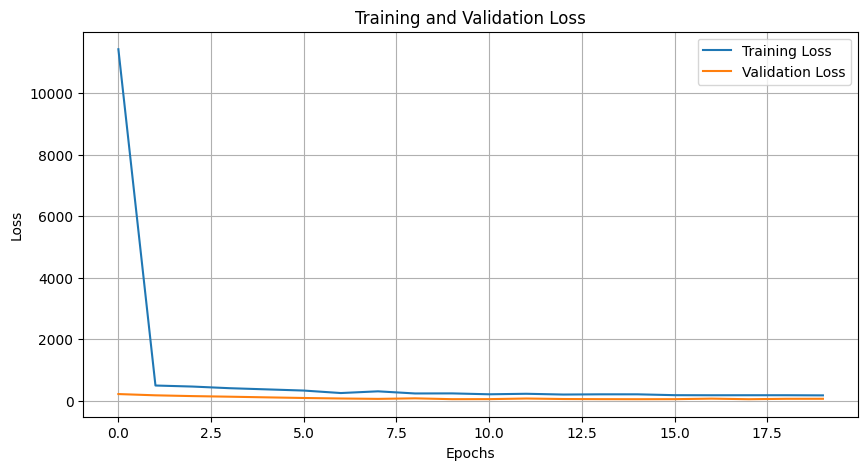

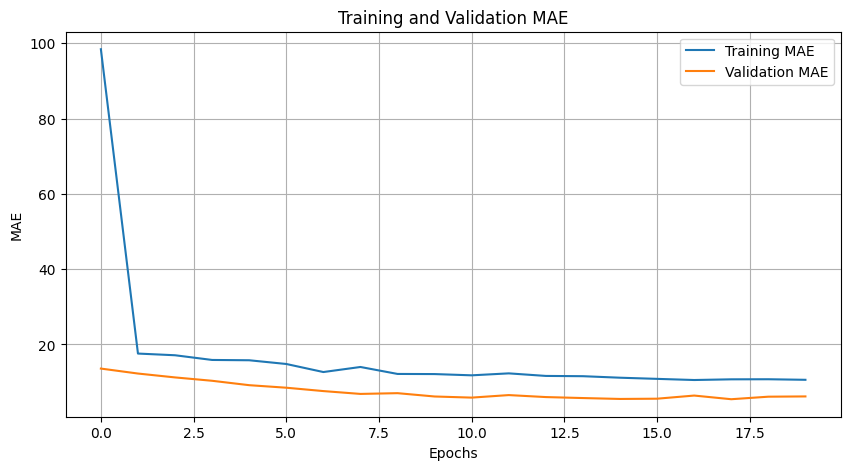

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

if 'mae' in history.history:
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Training and Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)
    plt.show()


## Model B: Predicts the average heart rate for the specific interval of the video under consideration.

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import layers, models, optimizers

In [27]:
def read_frame_at(cap, idx):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if not ret:
        raise RuntimeError(f"Failed to read frame {idx}")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, IMG_SIZE)
    frame = frame.astype(np.float32)/255.0
    return frame

def sample_frame_indices_interval(start, end, n_samples):
    total = end - start
    if total <= 0:
        return []
    if total <= n_samples:
        return list(range(start, end))
    return np.linspace(start, end-1, n_samples, dtype=int)

def get_hr_values(hr_csv_path):
    df = pd.read_csv(hr_csv_path)
    if 'HR' in df.columns:
        return df['HR'].values
    else:
        return df.select_dtypes(include=np.number).iloc[:,0].values

# -----------------------------
# VIDEO & HR META
# -----------------------------
video_dir = "/content/drive/MyDrive/HCI Project/Datasets/ibdts_processed_data/ibdts_processed_data/3D_Motion_Videos"
hr_dir = "/content/drive/MyDrive/HCI Project/Datasets/ibdts_processed_data/ibdts_processed_data/hr"

meta_list = []
for f in os.listdir(video_dir):
    if f.endswith(".mp4"):
        participant_id = f.split("_")[0]   # e.g., "p1"
        meta_list.append({
            "video_path": os.path.join(video_dir, f),
            "hr_path": os.path.join(hr_dir, f.replace(".mp4", "_hr.csv")),
            "participant": participant_id
        })

# -----------------------------
# TRAIN/VAL SPLIT (person-specific)
# -----------------------------
participants = list(set([m['participant'] for m in meta_list]))
train_parts, val_parts = train_test_split(participants, test_size=0.2, random_state=SEED)

train_meta = [m for m in meta_list if m['participant'] in train_parts]
val_meta = [m for m in meta_list if m['participant'] in val_parts]

In [28]:
def build_embedding_model(input_shape=(N_FRAMES, IMG_SIZE[0], IMG_SIZE[1], 3), embedding_dim=128):
    frames_input = layers.Input(shape=input_shape)

    def frame_cnn():
        inp = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
        x = layers.Conv2D(32,3,padding='same',activation='relu')(inp)
        x = layers.MaxPool2D()(x)
        x = layers.Conv2D(64,3,padding='same',activation='relu')(x)
        x = layers.MaxPool2D()(x)
        x = layers.Conv2D(128,3,padding='same',activation='relu')(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(embedding_dim, activation='relu')(x)
        return models.Model(inp,x)

    td = layers.TimeDistributed(frame_cnn())(frames_input)
    out = layers.GlobalAveragePooling1D()(td)
    return models.Model(frames_input, out, name="video_embedding_model")

embedding_model = build_embedding_model()
embedding_model.summary()

Model: "video_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8, 128, 128, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 8, 128)         │       109,760 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,760 (428.75 KB)

 Trainable params: 109,760 (428.75 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
def extract_embeddings_and_hr(meta_list):
    X_list, y_list = [], []
    for rec in meta_list:
        cap = cv2.VideoCapture(rec['video_path'])
        hr_vals = get_hr_values(rec['hr_path'])
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        interval_frames = FPS * INTERVAL_SECONDS
        n_intervals = total_frames // interval_frames

        for i in range(n_intervals):
            start = i * interval_frames
            end = start + interval_frames
            idxs = sample_frame_indices_interval(start, end, N_FRAMES)
            frames = [read_frame_at(cap, idx) for idx in idxs]
            if len(frames) < N_FRAMES:
                frames += [np.zeros_like(frames[0])]*(N_FRAMES - len(frames))
            frames_arr = np.stack(frames, axis=0)[np.newaxis,...]  # add batch dim

            emb = embedding_model.predict(frames_arr, verbose=0)[0]
            hr_start = int(round(start / FPS))
            hr_end = int(round(end / FPS))
            hr_cur = float(hr_vals[hr_start:min(hr_end,len(hr_vals))].mean())

            X_list.append(emb)
            y_list.append(hr_cur)

        cap.release()
    return np.stack(X_list), np.array(y_list)

X_train, y_train = extract_embeddings_and_hr(train_meta)
X_val, y_val = extract_embeddings_and_hr(val_meta)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

# -----------------------------
# REGRESSION MODEL
# -----------------------------
reg_input = layers.Input(shape=(X_train.shape[1],))
x = layers.Dense(128, activation='relu')(reg_input)
x = layers.Dense(64, activation='relu')(x)
out = layers.Dense(1, activation='linear')(x)
model_A = models.Model(reg_input, out)
model_A.compile(optimizer=optimizers.Adam(1e-4), loss='mse', metrics=['mae'])
model_A.summary()

# -----------------------------
# TRAIN
# -----------------------------
history = model_A.fit(X_train, y_train,
                      validation_data=(X_val, y_val),
                      epochs=30,
                      batch_size=8,
                      verbose=2)


Train: (508, 128) (508,)
Val: (128, 128) (128,)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,833 (97.00 KB)

 Trainable params: 24,833 (97.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
64/64 - 2s - 24ms/step - loss: 319.7745 - mae: 15.3556 - val_loss: 318.5540 - val_mae: 15.3152
Epoch 2/30
64/64 - 0s - 4ms/step - loss: 313.4684 - mae: 15.1488 - val_loss: 311.7397 - val_mae: 15.0910
Epoch 3/30
64/64 - 0s - 4ms/step - loss: 305.3812 - mae: 14.8795 - val_loss: 301.8958 - val_mae: 14.7613
Epoch 4/30
64/64 - 0s - 4ms/step - loss: 293.3730 - mae: 14.4704 - val_loss: 287.3001 - val_mae: 14.2583
Epoch 5/30
64/64 - 0s - 3ms/step - loss: 276.0989 - mae: 13.8945 - val_loss: 266.9557 - val_mae: 13.6446
Epoch 6/30
64/64 - 0s - 3ms/step - loss: 252.9763 - mae: 13.2424 - val_loss: 240.8106 - val_mae: 12.8918
Epoch 7/30
64/64 - 0s - 4ms/step - loss: 224.6145 - mae: 12.3901 - val_loss: 210.2091 - val_mae: 11.9258
Epoch 8/30
64/64 - 0s - 3ms/step - loss: 193.1154 - mae: 11.3403 - val_loss: 177.9987 - val_mae: 10.8477
Epoch 9/30
64/64 - 0s - 3ms/step - loss: 161.7906 - mae: 10.3932 - val_loss: 147.8043 - val_mae: 9.9939
Epoch 10/30
64/64 - 0s - 4ms/step - loss: 134.1633 - ma

In [30]:
y_pred = model_A.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)
corr = np.corrcoef(y_val.flatten(), y_pred.flatten())[0,1]

print(f"MAE: {mae:.2f} bpm")
print(f"RMSE: {rmse:.2f} bpm")
print(f"R²: {r2:.3f}")
print(f"Pearson correlation: {corr:.3f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
MAE: 8.00 bpm
RMSE: 9.17 bpm
R²: -0.000
Pearson correlation: -0.018


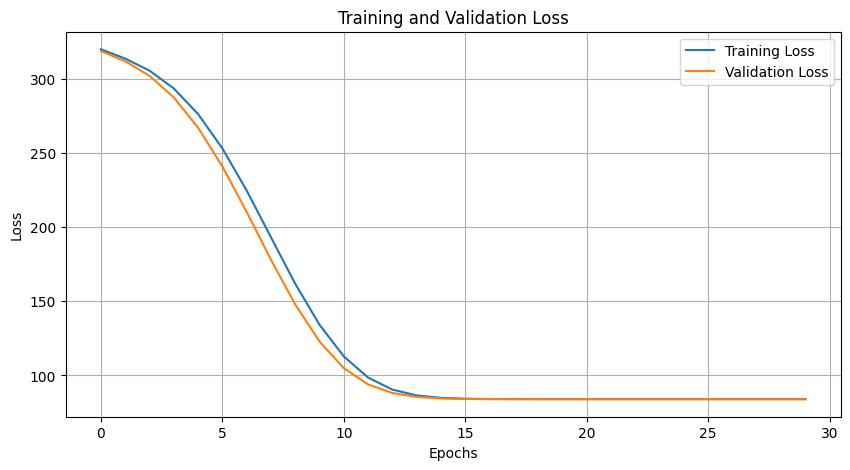

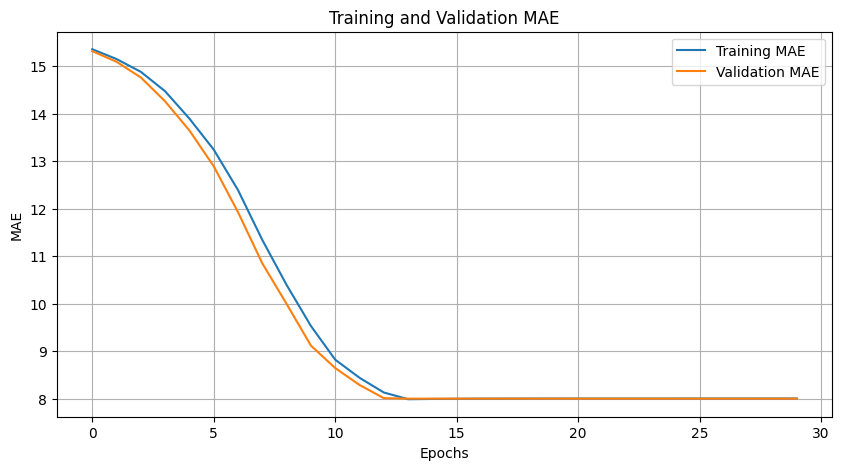

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

if 'mae' in history.history:
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Training and Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)
    plt.show()
